# 02 - Analyse des corrélations

Ce notebook analyse les corrélations entre les 8 ETF du portefeuille.

**Objectifs :**
- Matrice de corrélation sur la période complète
- Corrélations roulantes (évolution dans le temps)
- Identifier les paires anti-corrélées pour la diversification

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

ETF_TICKERS = ['SPY', 'EFA', 'EEM', 'TLT', 'HYG', 'GLD', 'VNQ', 'SH']

## 1. Chargement des données

In [2]:
# Charger les données
data_dir = Path('../data/processed')
dataset_file = sorted(data_dir.glob('dataset_*.csv'))[-1]

df = pd.read_csv(dataset_file, index_col=0, parse_dates=True)
prices = df[ETF_TICKERS].copy()

# Calculer les returns journaliers
returns = prices.pct_change().dropna()
print(f'Période: {returns.index.min().date()} → {returns.index.max().date()}')
print(f'Observations: {len(returns)}')

Période: 2010-01-05 → 2026-05-05
Observations: 4108


## 2. Matrice de corrélation (période complète)

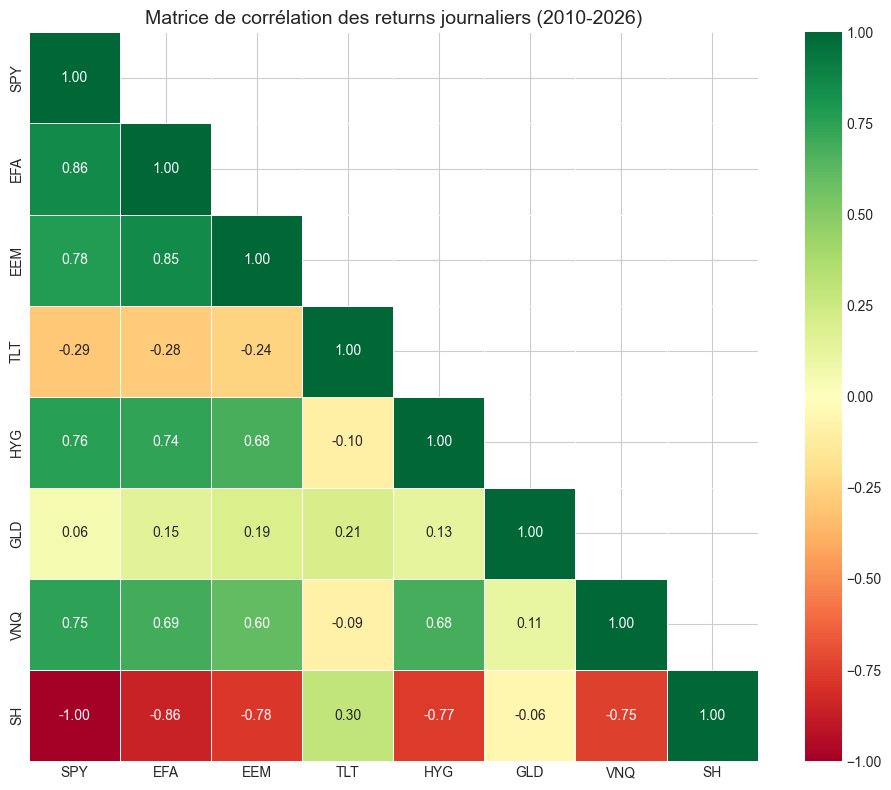

In [3]:
# Calculer la matrice de corrélation
corr_matrix = returns.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Matrice de corrélation des returns journaliers (2010-2026)', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Top paires les plus corrélées / anti-corrélées
corr_pairs = []
for i, t1 in enumerate(ETF_TICKERS):
    for t2 in ETF_TICKERS[i+1:]:
        corr_pairs.append({
            'Pair': f'{t1}/{t2}',
            'Correlation': corr_matrix.loc[t1, t2]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation')

print("=== Paires les plus ANTI-CORRÉLÉES (diversification) ===")
print(corr_df.head(5).to_string(index=False))

print("\n=== Paires les plus CORRÉLÉES ===")
print(corr_df.tail(5).to_string(index=False))

=== Paires les plus ANTI-CORRÉLÉES (diversification) ===
  Pair  Correlation
SPY/SH    -0.997843
EFA/SH    -0.858124
EEM/SH    -0.781090
HYG/SH    -0.765130
VNQ/SH    -0.748011

=== Paires les plus CORRÉLÉES ===
   Pair  Correlation
SPY/VNQ     0.746229
SPY/HYG     0.764877
SPY/EEM     0.781072
EFA/EEM     0.851758
SPY/EFA     0.858572


## 3. Corrélations roulantes

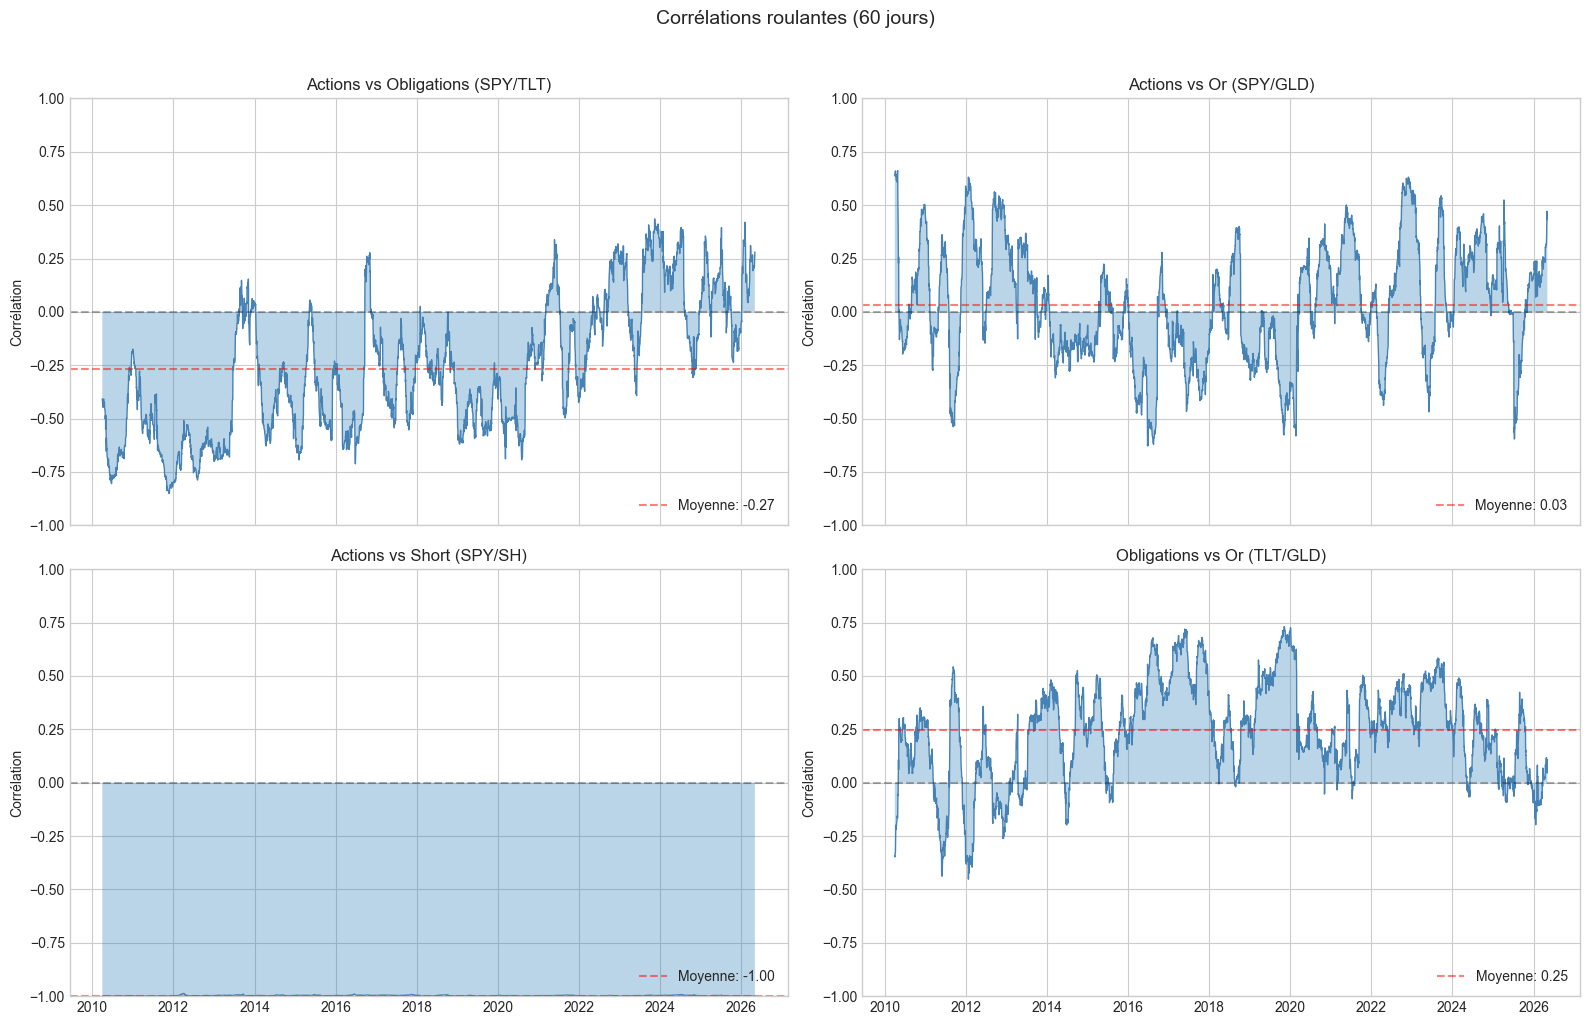

In [5]:
# Corrélations roulantes 60 jours
window = 60

# Paires intéressantes
pairs = [
    ('SPY', 'TLT', 'Actions vs Obligations'),
    ('SPY', 'GLD', 'Actions vs Or'),
    ('SPY', 'SH', 'Actions vs Short'),
    ('TLT', 'GLD', 'Obligations vs Or'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, (t1, t2, title) in zip(axes, pairs):
    rolling_corr = returns[t1].rolling(window).corr(returns[t2])
    
    ax.plot(rolling_corr.index, rolling_corr, color='steelblue', linewidth=1)
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.axhline(rolling_corr.mean(), color='red', linestyle='--', alpha=0.5, 
               label=f'Moyenne: {rolling_corr.mean():.2f}')
    ax.fill_between(rolling_corr.index, rolling_corr, 0, alpha=0.3)
    ax.set_title(f'{title} ({t1}/{t2})')
    ax.set_ylabel('Corrélation')
    ax.set_ylim(-1, 1)
    ax.legend(loc='lower right')

plt.suptitle(f'Corrélations roulantes ({window} jours)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

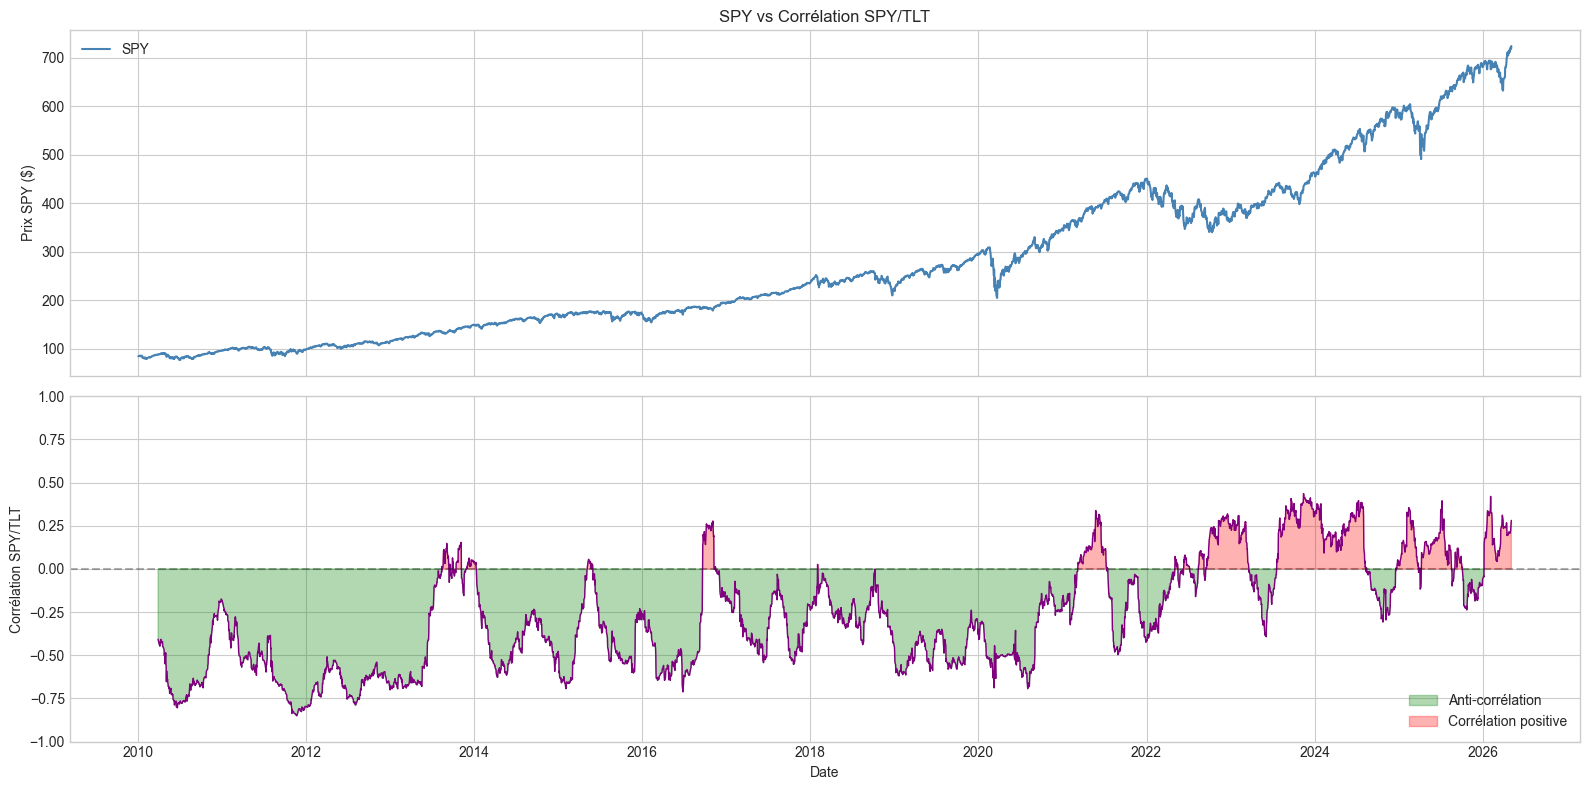

In [6]:
# Focus sur SPY/TLT pendant les crises
rolling_spy_tlt = returns['SPY'].rolling(60).corr(returns['TLT'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Prix SPY
ax = axes[0]
ax.plot(prices.index, prices['SPY'], label='SPY', color='steelblue')
ax.set_ylabel('Prix SPY ($)')
ax.legend(loc='upper left')
ax.set_title('SPY vs Corrélation SPY/TLT')

# Corrélation
ax = axes[1]
ax.plot(rolling_spy_tlt.index, rolling_spy_tlt, color='purple', linewidth=1)
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.fill_between(rolling_spy_tlt.index, rolling_spy_tlt, 0, 
                where=rolling_spy_tlt < 0, color='green', alpha=0.3, label='Anti-corrélation')
ax.fill_between(rolling_spy_tlt.index, rolling_spy_tlt, 0, 
                where=rolling_spy_tlt >= 0, color='red', alpha=0.3, label='Corrélation positive')
ax.set_ylabel('Corrélation SPY/TLT')
ax.set_xlabel('Date')
ax.set_ylim(-1, 1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## 4. Corrélations en période de stress vs normale

In [7]:
# Définir périodes de stress (VIX > 25 ou drawdown SPY > 10%)
spy_drawdown = (prices['SPY'] / prices['SPY'].cummax() - 1)
stress_mask = spy_drawdown < -0.10

print(f"Jours de stress (drawdown > 10%): {stress_mask.sum()} ({stress_mask.mean()*100:.1f}%)")
print(f"Jours normaux: {(~stress_mask).sum()}")

Jours de stress (drawdown > 10%): 507 (12.3%)
Jours normaux: 3602


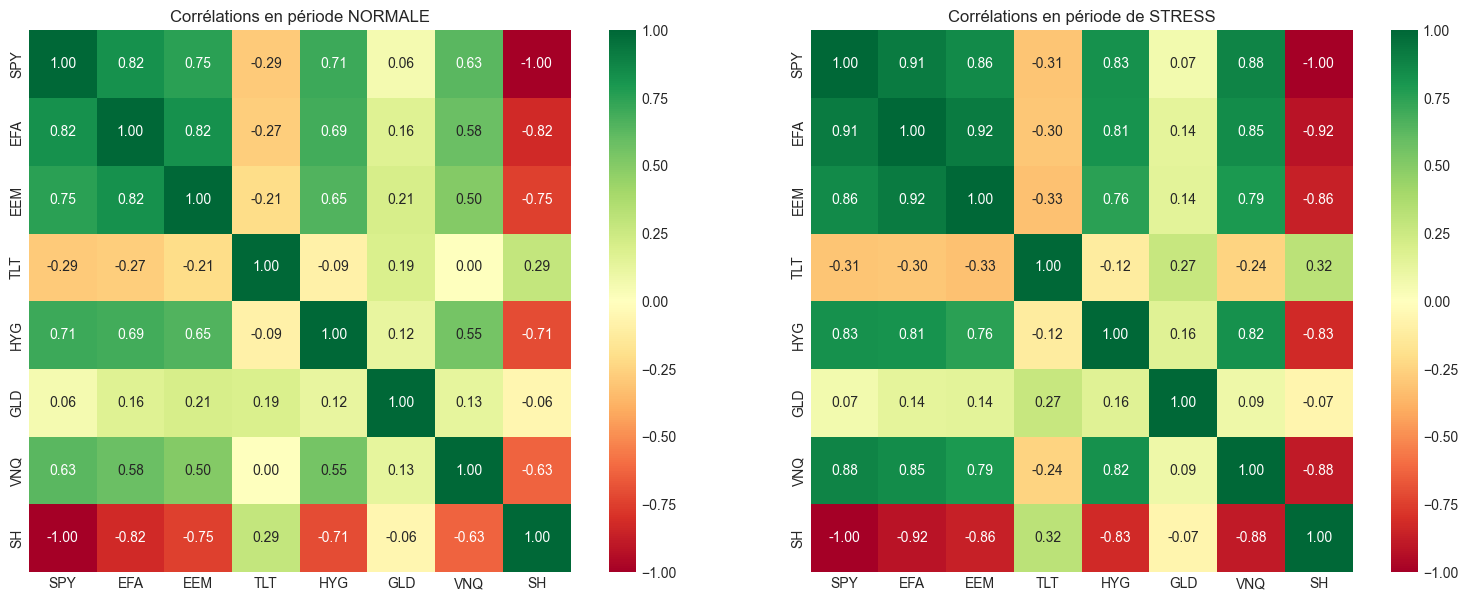

In [8]:
# Corrélations en période normale vs stress
returns_normal = returns[~stress_mask.reindex(returns.index).fillna(False)]
returns_stress = returns[stress_mask.reindex(returns.index).fillna(False)]

corr_normal = returns_normal.corr()
corr_stress = returns_stress.corr()

# Comparaison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.heatmap(corr_normal, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Corrélations en période NORMALE')

ax = axes[1]
sns.heatmap(corr_stress, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Corrélations en période de STRESS')

plt.tight_layout()
plt.show()

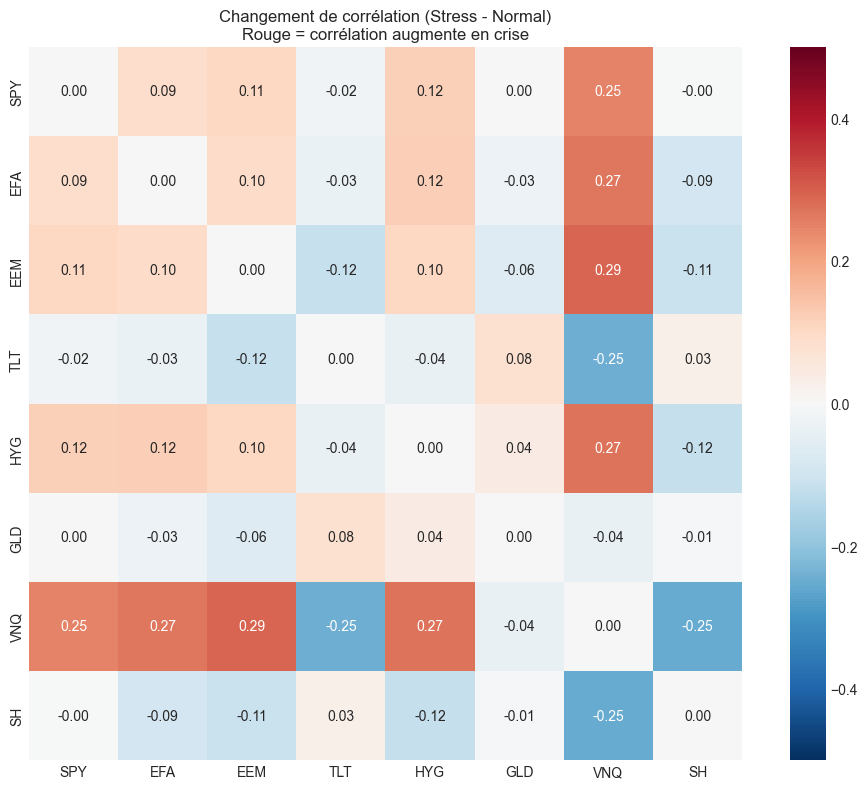

In [9]:
# Différence de corrélation stress - normal
corr_diff = corr_stress - corr_normal

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, square=True, ax=ax)
ax.set_title('Changement de corrélation (Stress - Normal)\nRouge = corrélation augmente en crise')
plt.tight_layout()
plt.show()

## 5. Insights clés

**Observations :**

1. **SPY/SH** : Corrélation ~ -0.99 (inverse parfait, comme attendu)

2. **SPY/TLT** : Corrélation négative (-0.3 à -0.5) → Flight to quality en crise

3. **GLD** : Faible corrélation avec tous les autres → Excellent diversificateur

4. **Actions (SPY, EFA, EEM, VNQ)** : Fortement corrélées entre elles (~0.7-0.9)

5. **En période de stress** :
   - Les corrélations entre actions AUGMENTENT ("corrélations go to 1")
   - SPY/TLT devient PLUS négative (flight to quality)
   - GLD reste relativement décorrélé

**Implications pour le portefeuille :**
- TLT et GLD apportent une vraie diversification
- SH peut servir de hedge en bear market
- La diversification géographique (EFA, EEM) est moins efficace qu'on pourrait le penser